# 🎲 Probabilidad y distribuciones

## Probabilidad 
La probabilidad mide el grado de incertidumbre de un evento. En el análisis de datos, permite estimar qué tan probable es obtener un determinado resultado, generalmente a partir de una pregunta o hipótesis planteada.

## Distribuciones
Las distribuciones describen cómo se reparten los valores o probabilidades de una variable, mostrando qué resultados son más o menos probables.


----


- ### Hipótesis
Es una afirmación o suposición sobre un fenómeno o parámetro que se formula para ser evaluada con datos y determinar su probabilidad o validez. 

- ### Intervalo de confianza
Es un rango de valores dentro del cual, con cierto nivel de confianza (por ejemplo, 95%), se espera que se encuentre el valor real de un parámetro al evaluar una hipótesis.

- ### Z-score: Estandarizar para comparar:   
Es una medida que indica cuántas desviaciones estándar se aleja un valor de la media. Sirve para comparar valores en distintas escalas y para saber si un dato es típico o inusual dentro de una distribución.   
Un Z‑score positivo significa que el valor está por encima de la media; uno negativo, por debajo.   
Valores con |Z| > 2 suelen considerarse poco comunes.

- ### p-value.
Es la probabilidad de obtener resultados tan extremos como los observados (o más), suponiendo que la hipótesis nula es verdadera.

# Consumo de la API publica y creacion del dataframe.

In [ ]:
import requests
import pandas as pd

BASE_URL = "https://restcountries.com/v3.1/all?fields=name,area,population,region,gini"

def get_country_data():
    response = requests.get(BASE_URL)

    data = response.json()
    results = []

    for country in data:
        results.append({
            "name": country["name"]["common"],
            "area": country.get("area", "N/A"),
            "population": country.get("population", "N/A"),
            "region": country.get("region", "N/A")
        })

    return pd.DataFrame(results)

df = get_country_data()

# Calcular todo a la vez. Interpretación: 
#   count: Cantidad de valores
#   mean: Media
#   std: Desviación estándar
#   min, 25%, 50%, 75%, max: Percentiles

print(df.describe().astype(str))

print("Paises con población = 0:", len(df[df["population"] == 0]))


                     area          population
count               250.0               250.0
mean    601038.8508400001         32077981.84
std    1912575.3624724457  131965523.42651032
min                  0.49                 0.0
25%               1194.25           223354.25
50%               64929.5           5279123.0
75%              384150.5         20371664.25
max            17098246.0        1417492000.0
Paises con población = 0: 5


# Distribución normal (Gaussiana)

Es la distribución de probabilidad continua más importante en estadística. 
Está completamente definida por:
μ (mu): la media → indica el centro de la distribución 
σ (sigma): la desviación estándar → indica qué tan dispersos están los datos.  
Propiedades clave:  
La mayoría de los valores se concentran alrededor de μ 
Es simétrica: izquierda = derecha.   
Regla empírica (68-95-99.7):   
~68% de los datos están en μ ± 1σ   
~95% en μ ± 2σ   
~99.7% en μ ± 3σ.   
    
Características:
- Forma de campana
- Simétrica respecto a la media
- Definida por μ (media) y σ (desviación estándar)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Calcular estadísticas de población
mu = np.mean(df["population"].astype(float))
sigma = np.std(df["population"].astype(float))

print(f"Media de la población: {mu:,.0f}")
print(f"Desviación estándar: {sigma:,.0f}")


Media de la población: 32,077,982
Desviación estándar: 131,701,328


Rango de población: 0 - 1,417,492,000


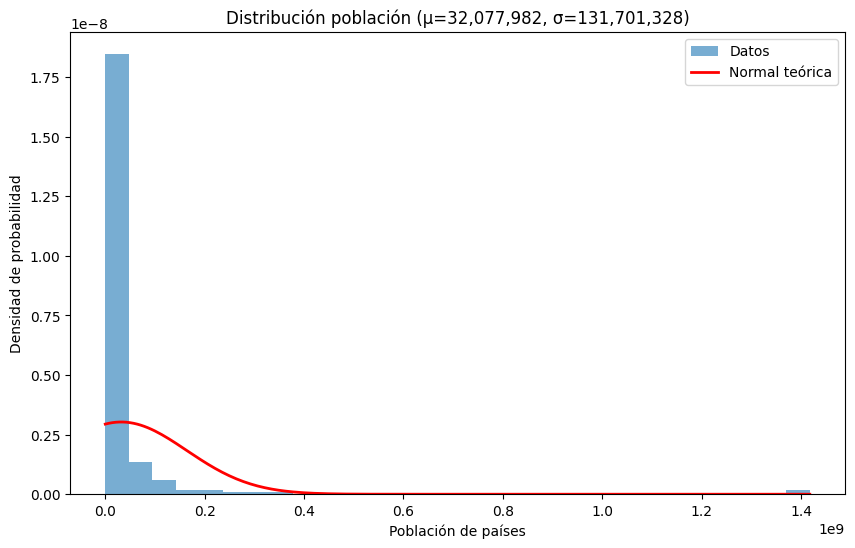

In [ ]:
# Visualizar
datos = df["population"].astype(float)

plt.figure(figsize=(10, 6))                                         # Abre una ventana gráfica de 10 × 6 pulgadas
plt.hist(datos, bins=30, density=True, alpha=0.6, label='Datos')   #bins=30: divide en 30 barras; density=True: normaliza para que el área sea 1; alpha=0.6: transparencia al 60%;  label='Datos': etiqueta para la leyenda

# Curva teórica
p_min = datos.min()
p_max = datos.max()

print(f"Rango de población: {p_min:,.0f} - {p_max:,.0f}")

x = np.linspace(p_min, p_max, 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal teórica')  # norm.pdf(): calcula la altura de la curva de Gauss en cada punto x;  'r-': línea roja continua;  linewidth=2: grosor de 2 píxeles
plt.xlabel('Población de países')
plt.ylabel('Densidad de probabilidad')
plt.title(f'Distribución población (μ={mu:,.0f}, σ={sigma:,.0f})')
plt.legend()
plt.show()

    Eje X (horizontal):
Valores de la variable (en nuestro caso: población de países).
Va desde el mínimo al máximo de los datos (o el rango que definas con np.linspace).
Unidades: habitantes (ej: 0, 10M, 100M, 1.4B).

    Eje Y (vertical):
Densidad de probabilidad (no frecuencia absoluta).
Mide qué tan probable es cada valor.

    Por qué densidad?
density=True en plt.hist() normaliza el histograma para que el área total sea 1.
norm.pdf() calcula la altura de la curva gaussiana en cada punto.

    Interpretación: 
Alturas más altas = valores más comunes.
Si el histograma llega a 0.000001 en Y, significa que poblaciones alrededor de ese valor son muy raras.

La curva roja es la "forma ideal" de una normal.

¿Por qué densidad en lugar de conteo?
Para comparar histograma con curva teórica (ambos en escala de probabilidad).
Si usas density=False, Y sería conteo de países, y la curva no se alinearía.
Si quieres cambiar a conteo absoluto, quita density=True y ajusta la curva multiplicando por el total de datos.


# Teorema Central del Límite (TCL)
Dice que, si tomamos muchas muestras grandes de cualquier población, la distribución de sus medias se vuelve aproximadamente normal, sin importar cómo sean los datos originales. Esto permite usar métodos basados en la normal incluso cuando la población no lo es.   
"La distribución de las medias muestrales tiende a ser normal, sin importar la distribución original."

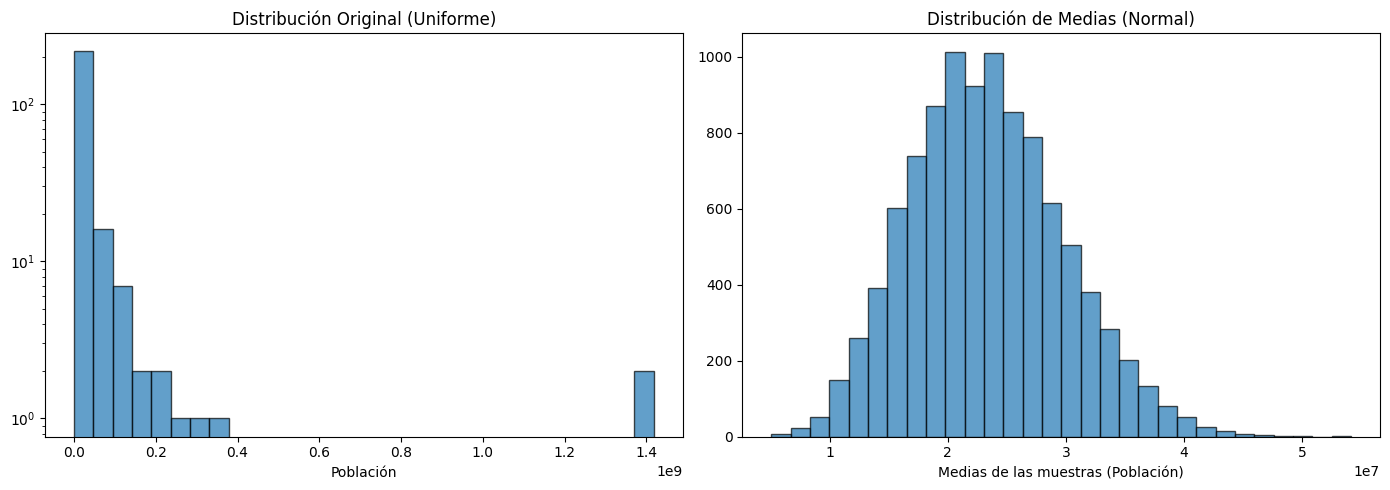

In [ ]:
# Distribución uniforme (NO normal)
poblacion = df["population"].dropna()
muestra = poblacion.sample(n=30, replace=False)  # Muestra de tamaño 30 sin reemplazo

medias_muestrales = [muestra.sample(n=30, replace=True).mean() for _ in range(10000)]

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original (uniforme)
axes[0].hist(poblacion, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución Original (Uniforme)')
axes[0].set_xlabel('Población')
axes[0].set_yscale("log")

# Distribución de medias (normal!)
axes[1].hist(medias_muestrales, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de Medias (Normal)')
axes[1].set_xlabel('Medias de las muestras (Población)')

plt.tight_layout()
plt.show()


# Z-score: Estandarizar valores

Es una medida que indica cuántas desviaciones estándar se aleja un valor de la media.
Sirve para comparar valores en distintas escalas y para saber si un dato es típico o inusual dentro de una distribución.   
Un Z‑score positivo significa que el valor está por encima de la media; uno negativo, por debajo.   
Valores con |Z| > 2 suelen considerarse poco comunes.

Convierte valores a "cuántas desviaciones estándar están de la media".

In [ ]:
x = df["population"]
df["z_score"] = (x - mu) / sigma
print(df[["name", "population", "z_score"]].head())

print(f"Z-score: {df["z_score"]}")  # 1.0 (está 1 desviación estándar por encima)

# Interpretar
df["interpretacion"] = df["z_score"].apply( 
    lambda z: "Por encima de la media" if z > 0 else ("Por debajo de la media" if z < 0 else "En la media") 
    ) 
print(df[["name", "population", "z_score", "interpretacion"]])



               name  population   z_score
0      Cook Islands       15040 -0.243452
1            Guinea    14363931 -0.134502
2  Christmas Island        1692 -0.243553
3              Togo     8095498 -0.182098
4            Taiwan    23317031 -0.066521
Z-score: 0     -0.243452
1     -0.134502
2     -0.243553
3     -0.182098
4     -0.066521
         ...   
245    0.613160
246   -0.027038
247   -0.240108
248   -0.197176
249   -0.194688
Name: z_score, Length: 250, dtype: float64
                 name  population   z_score          interpretacion
0        Cook Islands       15040 -0.243452  Por debajo de la media
1              Guinea    14363931 -0.134502  Por debajo de la media
2    Christmas Island        1692 -0.243553  Por debajo de la media
3                Togo     8095498 -0.182098  Por debajo de la media
4              Taiwan    23317031 -0.066521  Por debajo de la media
..                ...         ...       ...                     ...
245          DR Congo   112832000  0.613160 

# Intervalos de confianza

Un intervalo que probablemente contiene el parámetro poblacional.
IC para la media (σ conocida)

In [ ]:
muestra = df["population"].sample(n=30, random_state=42) 
ic = stats.t.interval( 
    confidence=0.95, df=len(muestra) - 1, loc=muestra.mean(), scale=stats.sem(muestra) 
    ) 
print(f"Media muestral: {muestra.mean():,.0f}") 
print(f"IC 95%: [{ic[0]:,.0f} , {ic[1]:,.0f}]") 
print(f"Media real (población): {mu:,.0f}") 
print(f"¿Está dentro del IC? {'Sí' if ic[0] <= mu <= ic[1] else 'No'}")

Media muestral: 32,206,800
IC 95%: [4,532,329 , 59,881,271]
Media real (población): 32,077,982
¿Está dentro del IC? Sí


# Pruebas de hipótesis

Método para validar afirmaciones sobre una población.
Estructura

1. Hipótesis nula (H₀): La afirmación por defecto (ej: μ = 100)
2. Hipótesis alternativa (H₁): Lo que queremos probar (ej: μ ≠ 100)
3. Nivel de significancia (α): Usualmente 0.05 (5%)
4. Calcular estadístico de prueba
5. Calcular p-value
6. Decisión: Si p < α, rechazar H₀

Se utiliza el metodo de descarte por error: Si la hipótesis (H) es verdadera, entonces ocurren consecuencias (C). (H –> C), pero si
observamos que C no ocurre. (-C) Por lo tanto, la hipótesis H es falsa. (-H).
Mientras que ningún número de observaciones puede verificar una teoría universal (ej: "todos los cisnes son blancos"), una sola observación contraria puede falsarla.



### ¿La población media es diferente de 30 millones? 

In [ ]:
t_stat, p_value = stats.ttest_1samp(df["population"], 30_000_000) 

print("=== HIPÓTESIS 1: Una muestra ===") 
print(f"H0: La población media = 30 millones") 
print(f"H1: La población media ≠ 30 millones") 
print(f"t: {t_stat:.2f} | p-value: {p_value:.4f}") 
print("Rechazamos H0 ✓" if p_value < 0.05 else "No rechazamos H0")

=== HIPÓTESIS 1: Una muestra ===
H0: La población media = 30 millones
H1: La población media ≠ 30 millones
t: 0.25 | p-value: 0.8036
No rechazamos H0


## p-value.
Es la probabilidad de obtener resultados tan extremos como los observados (o más), suponiendo que la hipótesis nula es verdadera. Dicho de otra manera es la probabilidad de obtener estos datos (o más extremos) si H₀ fuera cierta.

    p < 0.05: Resultado improbable bajo H₀ → Rechazamos H₀
    p ≥ 0.05: Resultado plausible bajo H₀ → No rechazamos H₀

⚠️ Malentendidos comunes:

❌ "p = 0.03 significa que H₀ tiene 3% de probabilidad"
✅ "Si H₀ fuera cierta, tendríamos 3% de probabilidad de ver estos datos"

❌ "p = 0.06 significa que no hay efecto"
✅ "No tenemos evidencia suficiente para rechazar H₀"

### ¿Asia tiene mayor población media que Europa?

In [ ]:
asia = df[df["region"] == "Asia"]["population"] 
europa = df[df["region"] == "Europe"]["population"] 
print(f"Media Asia: {asia.mean():,.0f} | Media Europa: {europa.mean():,.0f}")

t_stat, p_value = stats.ttest_ind(asia, europa) 
print("\n=== HIPÓTESIS 2: Dos muestras independientes ===") 
print(f"H0: La población media de Asia = Europa") 
print(f"H1: La población media de Asia ≠ Europa") 
print(f"t: {t_stat:.2f} | p-value: {p_value:.4f}") 
print("Rechazamos H0 ✓" if p_value < 0.05 else "No rechazamos H0")

Media Asia: 94,494,639 | Media Europa: 13,993,546

=== HIPÓTESIS 2: Dos muestras independientes ===
H0: La población media de Asia = Europa
H1: La población media de Asia ≠ Europa
t: 2.10 | p-value: 0.0385
Rechazamos H0 ✓


### ¿Los países con z > 1 tienen población significativamente mayor?

In [ ]:
normales = df[df["z_score"] <= 1]["population"] 
extremos = df[df["z_score"] > 1]["population"] 

t_stat, p_value = stats.ttest_ind(extremos, normales) 
print("\n=== HIPÓTESIS 3: Z-score ===") 
print(f"H0: Países con z>1 tienen la misma media que el resto") 
print(f"H1: Países con z>1 tienen mayor media") 
print(f"t: {t_stat:.2f} | p-value: {p_value:.4f}") 
print("Rechazamos H0 ✓" if p_value < 0.05 else "No rechazamos H0")



=== HIPÓTESIS 3: Z-score ===
H0: Países con z>1 tienen la misma media que el resto
H1: Países con z>1 tienen mayor media
t: 15.33 | p-value: 0.0000
Rechazamos H0 ✓


### Errores:   
- Un error hubiera sido quitar los valores que tienen 0 porque (al menos para nosotros) esos valores atípicos tienen valor en cuanto a que son valores reales e inciden en los datos. Si tenemos en cuanta todos los países, consideramos que estos deben permanecer.   
- Se podría cometer el error de quedarse con la primera curva de distribución que apareciera en la Teoría Central del Límite. Ya que siendo los datos tan extremos, a veces aparecen curvas que no cumplen el Teorema. Al probar varias veces y al aumentar las muestras, se comprobaba que el Teorema se cumple.  
- Se podría cometer el error de confundir desviaciones típicas, varianzas y puntuaciones z.    
- Negociar poco

